In [1]:
%load_ext autoreload
%autoreload 2
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import  TensorDataset, DataLoader

from data import get_y, get_dataloader
from config_mounir import NearOODFramework
from eval_functions import train, auc_and_fpr_recall, visualize, calc_outputs_test, calc_correlations, separabilite, performance_report
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
torch.cuda.is_available()

/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
seed = 42  
torch.manual_seed(seed)
np.random.seed(seed)

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Préparation des données

In [18]:
root_dir = "/data/maouche/MultiOOD/HMDB-rgb-flow/saved_files/"
datasets = ['HMDB', 'UCF', 'EPIC']
modalities = ['video', 'flow'] #

## Création des datasets

Les scores de confiance qu'on va utiliser ont été générés via des modèles différents, chaque modèle entraîné sur un des 3 datasets, ce qui fait que leurs scores ne sont pas forcément comparables. On doit donc entraîner un modèle sur chaque dataset séparément.

Données ID

In [19]:
template_sans_ash =  "id_{}_near_ood_conf_baseline_best_test.npy"
template_ash_tout = "id_{}_near_ood_conf_baseline_best_ash_test.npy"
template_par_modalite = "id_{}_near_ood_conf_baseline_best_ash_{}_test.npy"

datasets_id = {}

for dataset in datasets:

    # Sans ash
    conf_sans_ash = np.load(root_dir+template_sans_ash.format(dataset))
    conf_sans_ash = conf_sans_ash.reshape(conf_sans_ash.shape[0], 1)

    # ash sur tout
    conf_ash_tout = np.load(root_dir+template_ash_tout.format(dataset))
    conf_ash_tout = conf_ash_tout.reshape(conf_ash_tout.shape[0], 1)


    # ash par modalité
    conf_une_modalite = []
    for modality in modalities:
        x = np.load(root_dir+template_par_modalite.format(dataset, modality))
        x = x.reshape(x.shape[0], 1)
        conf_une_modalite.append(x)
    conf_une_modalite = np.hstack(conf_une_modalite)

    dataset_id = np.hstack([conf_sans_ash, conf_ash_tout, conf_une_modalite]) #(N,5)
    datasets_id[dataset] = dataset_id

Données OOD

In [20]:
template_sans_ash =  "id_{}_near_ood_conf_baseline_best_eval.npy"
template_ash_tout = "id_{}_near_ood_conf_baseline_best_ash_eval.npy"
template_par_modalite = "id_{}_near_ood_conf_baseline_best_ash_{}_eval.npy"

datasets_ood = {}
for dataset in datasets:
    # Sans ash
    conf_sans_ash = np.load(root_dir+template_sans_ash.format(dataset))
    conf_sans_ash = conf_sans_ash.reshape(conf_sans_ash.shape[0], 1)

    # ash sur tout
    conf_ash_tout = np.load(root_dir+template_ash_tout.format(dataset))
    conf_ash_tout = conf_ash_tout.reshape(conf_ash_tout.shape[0], 1)


    # ash par modalité
    conf_une_modalite = []
    for modality in modalities:
        x = np.load(root_dir+template_par_modalite.format(dataset, modality))
        x = x.reshape(x.shape[0], 1)
        conf_une_modalite.append(x)
    conf_une_modalite = np.hstack(conf_une_modalite)

    dataset_ood = np.hstack([conf_sans_ash, conf_ash_tout, conf_une_modalite]) #(N,4)
    datasets_ood[dataset] = dataset_ood

In [21]:
X = {}
for (name_id, dataset_id), (name_ood, dataset_ood) in list(zip(datasets_id.items(), datasets_ood.items())):
    X[name_id] = np.vstack([dataset_id, dataset_ood])
    
#X = np.vstack([dataset_id, dataset_ood])

In [22]:
len(X["HMDB"]), len(X["UCF"]), len(X["EPIC"])

(4203, 7646, 1856)

Création des labels

In [23]:
# inutile mais bon pour visualisation
template_label_id =  "id_EPIC_near_ood_label_baseline_best_test.npy"
labels_id = np.load(root_dir+template_label_id)

template_label_ood =  "id_EPIC_near_ood_label_baseline_best_eval.npy"
labels_ood = np.load(root_dir+template_label_ood)
print(np.unique(labels_id, return_counts=True), len(labels_id))
print(np.unique(labels_ood, return_counts=True), len(labels_ood))


(array([0, 1, 2, 3]), array([174, 211,  84,  67])) 536
(array([4, 5, 6, 7]), array([1053,  139,   54,   74])) 1320


In [24]:
Y = {}
for dataset in datasets:
    y_id = np.zeros(datasets_id[dataset].shape[0])
    y_id = y_id.reshape(y_id.shape[0], 1)
    y_ood = np.ones(datasets_ood[dataset].shape[0])
    y_ood = y_ood.reshape(y_ood.shape[0], 1)

    Y[dataset] = np.vstack([y_id, y_ood])

In [25]:
for dataset in datasets:
    print(X[dataset].shape, Y[dataset].shape)

(4203, 4) (4203, 1)
(7646, 4) (7646, 1)
(1856, 4) (1856, 1)


## Création des dataloaders

In [26]:
data = {}
for dataset in datasets:    
    X_train, X_test, y_train, y_test = train_test_split(
                    X[dataset], Y[dataset], stratify=Y[dataset], test_size=0.2, random_state=42)

    data[dataset] = {"X_train":X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test}

In [27]:
with open("data_near.pkl", 'wb') as f:
    pickle.dump(data, f)

# Chargement

In [3]:
with open("data_near.pkl", 'rb') as f:
    data_all = pickle.load(f)

# Dataset HMDB

## Chargement des données

In [7]:
data = data_all["HMDB"]

train_dataloader = get_dataloader(data["X_train"], data["y_train"], batch_size=128) 
test_dataloader = get_dataloader(data["X_test"], data["y_test"], batch_size=128) 

3362 elements (array([0., 1.], dtype=float32), array([ 367, 2995]))
841 elements (array([0., 1.], dtype=float32), array([ 92, 749]))


In [ ]:
# X_tensor_train = torch.tensor(data['X_train'], dtype=torch.float32)
# y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
# train_dataset = TensorDataset(X_tensor_train, y_tensor_train)
# train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
# print(len(X_tensor_train), "elements", np.unique(y_tensor_train, return_counts=True)) 

3362 elements (array([0., 1.], dtype=float32), array([ 367, 2995]))


In [ ]:
# X_tensor_test = torch.tensor(data['X_test'], dtype=torch.float32)
# y_tensor_test = torch.tensor(data['y_test'], dtype=torch.float32)
# test_dataset = TensorDataset(X_tensor_test, y_tensor_test)
# test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=True)
# print(len(X_tensor_test), "elements", np.unique(y_tensor_test, return_counts=True))

841 elements (array([0., 1.], dtype=float32), array([749,  92]))


## Modèle

In [8]:
input_dim = 4  #ash sur tous + ash sur aucun + ash video + ash flow + ash audio
hidden_dim = 2
output_dim = 1

# Calcul des poids des classes
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

0.12253756260434057

## Entrainement

cuda
accuracy train:  0.6641476043948421


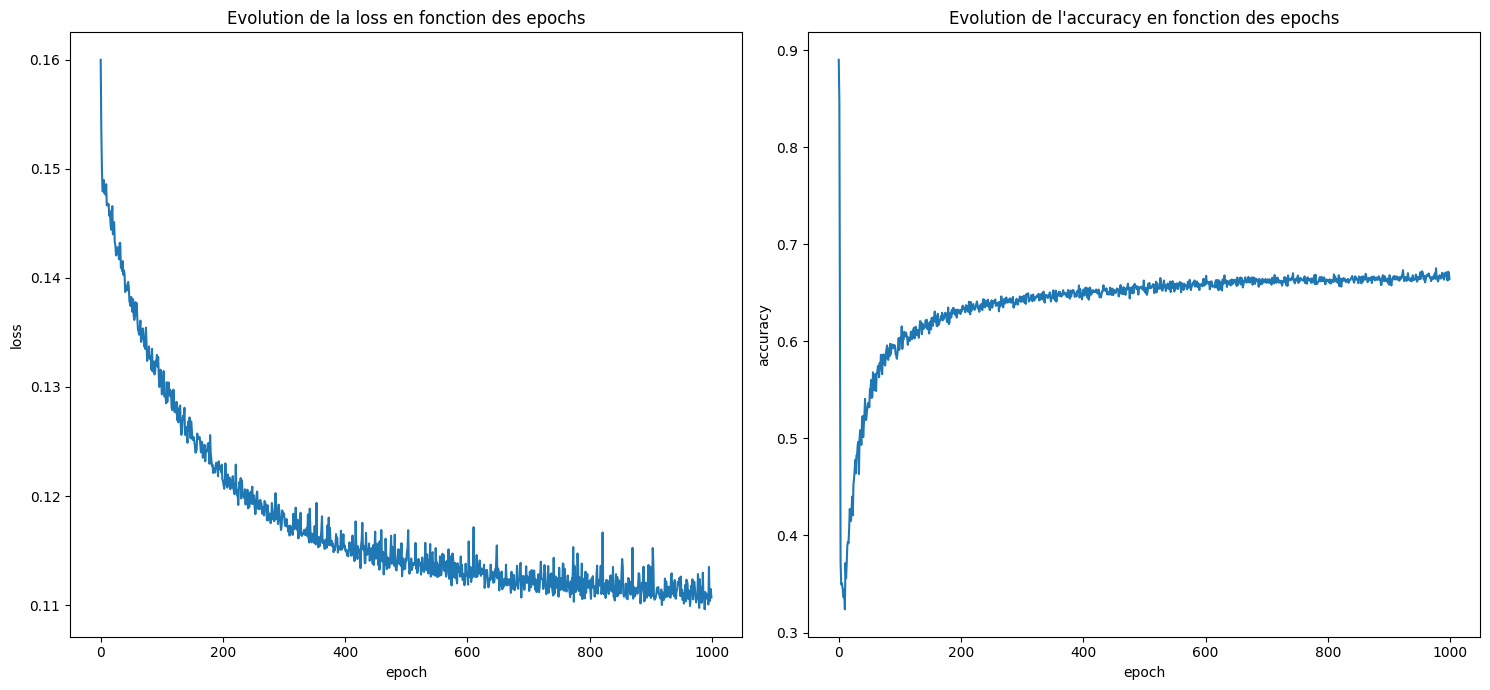

cuda
accuracy train:  0.6824618732487714


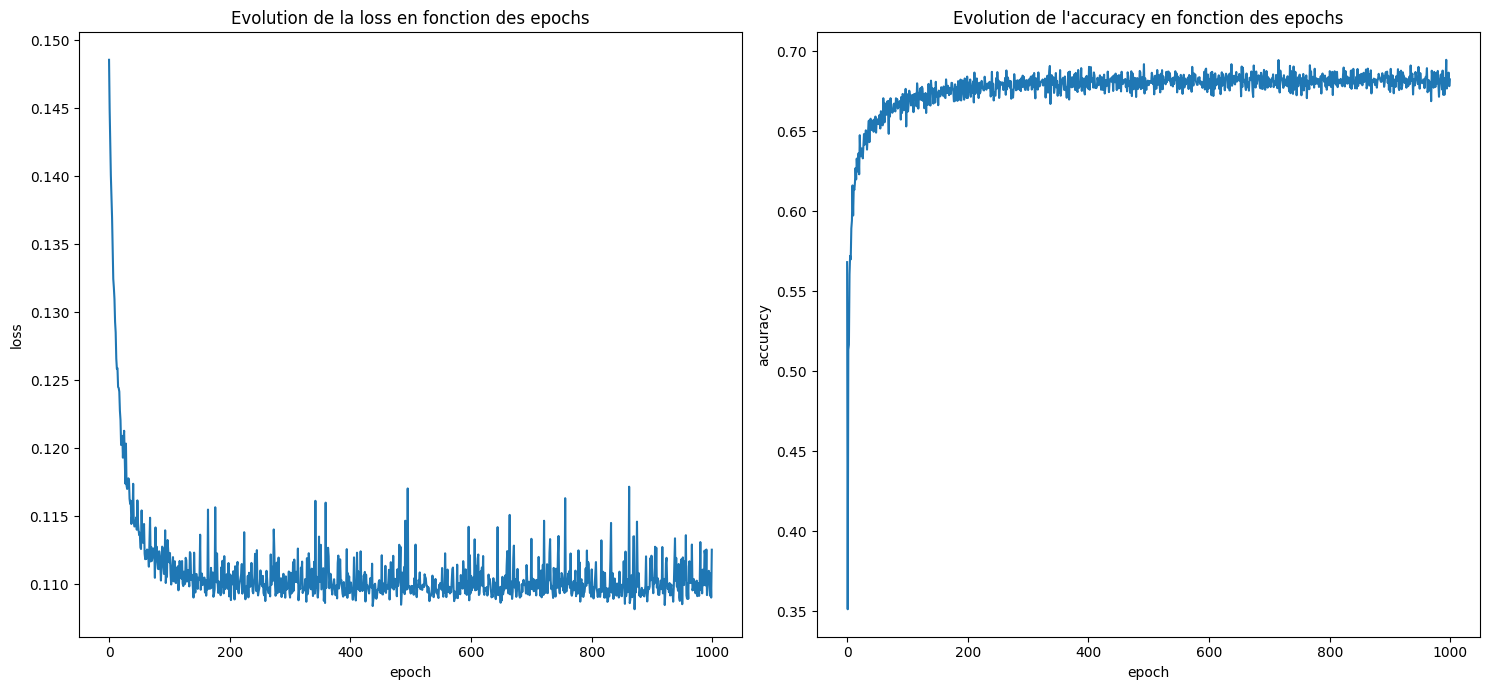

cuda
accuracy train:  0.6827682455380758


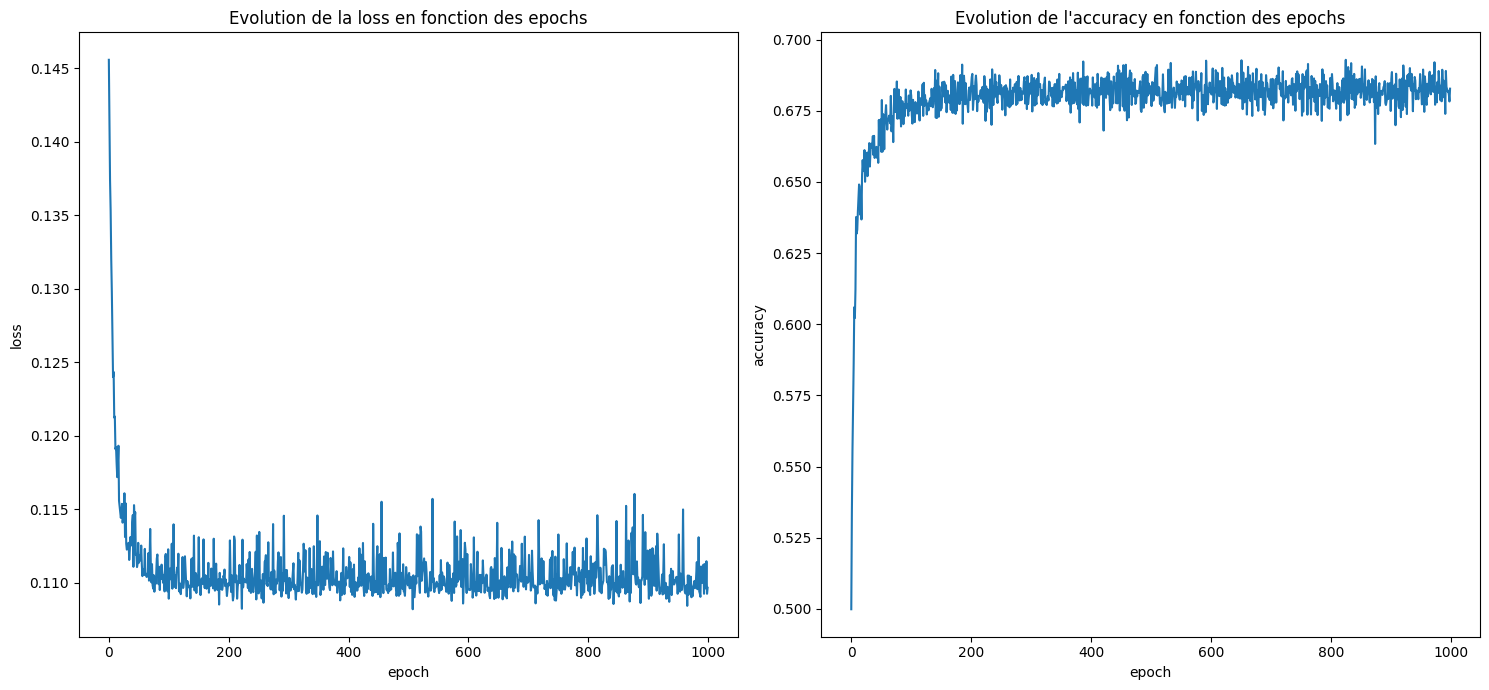

In [ ]:
nb_epochs = 1000
models = {}
for lr in [1e-1, 1, 2]:
    model = nn.Linear(input_dim, output_dim)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)

    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

In [ ]:
model = models[1]
torch.save(model.state_dict(), "model_near2.pth")

for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)

weight
tensor([[-7.0768,  2.7553, -1.5922, -2.1439]], device='cuda:0')
bias
tensor([7.1009], device='cuda:0')


Accuracy test:  0.8906
Séparabilité:


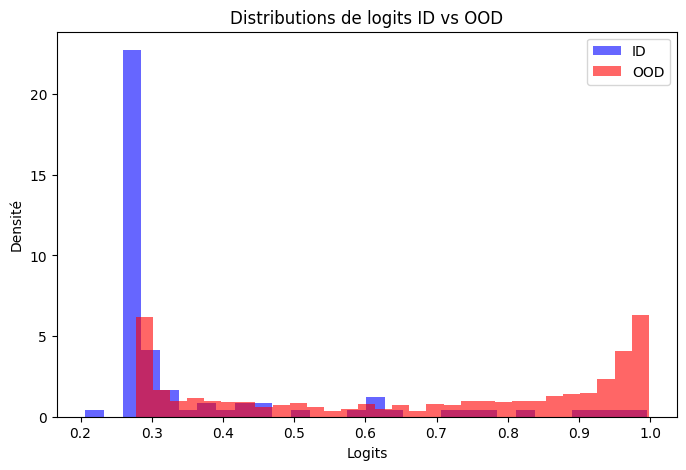

AUC ROC: 0.8528
FPR@TPR95: 0.5217

Correlation ID :  0.9128349790461882
Correlation OOD :  0.922521732381206


,config,tout,video,flow
0,poids_near_ood,2.7553,-1.5922,-2.1439
1,perturbation_near_ood_id,0.0052,0.0035,0.0018
2,perturbation_near_ood_ood,0.0211,0.0137,0.0069


In [36]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, NearOODFramework("near_ood"))

## 2 couches

cuda
accuracy train:  0.7373706433508131


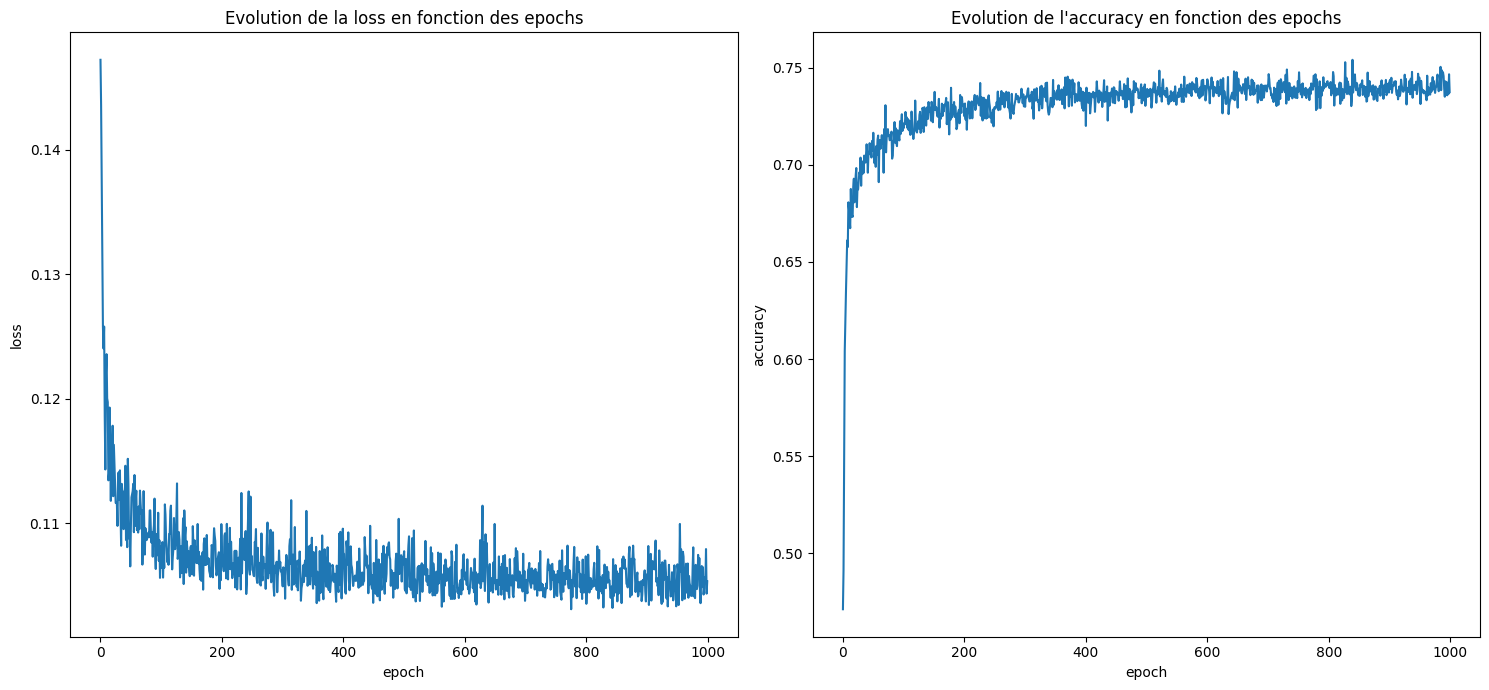

In [13]:
nb_epochs = 1000
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
optim = torch.optim.SGD(model.parameters(), lr=2)

plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
visualize(plot_loss, plot_acc)

In [ ]:
#torch.save(model.state_dict(), "model_hmdb_2c.pth")

In [ ]:
input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
output_dim = 1
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))
#model = nn.Linear(input_dim, output_dim)

model.load_state_dict(torch.load("model_near_hmdb_2c.pth"))

<All keys matched successfully>

Accuracy test:  0.8906
Séparabilité:


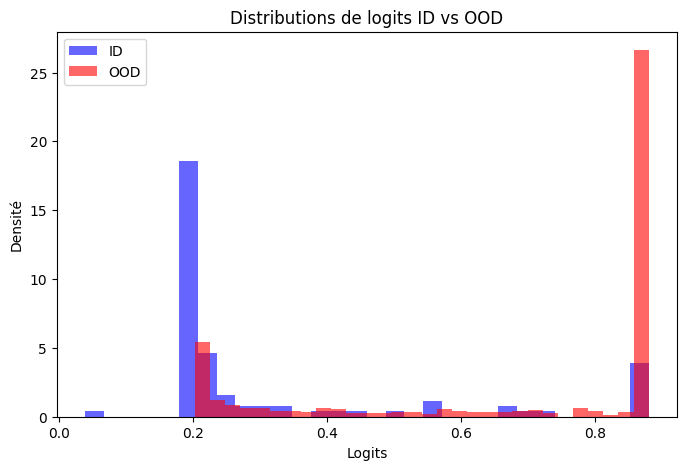

AUC ROC: 0.8438
FPR@TPR95: 0.5217



In [18]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, NearOODFramework("near_ood"), correlations=False)

# Dataset UCF

## Chargement des données

In [19]:
data = data_all["UCF"]

In [20]:
X_tensor_train = torch.tensor(data['X_train'], dtype=torch.float32)
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
train_dataset = TensorDataset(X_tensor_train, y_tensor_train)
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
print(len(X_tensor_train), "elements", np.unique(y_tensor_train, return_counts=True)) 

6116 elements (array([0., 1.], dtype=float32), array([ 824, 5292]))


In [22]:
X_tensor_test = torch.tensor(data['X_test'], dtype=torch.float32)
y_tensor_test = torch.tensor(data['y_test'], dtype=torch.float32)
test_dataset = TensorDataset(X_tensor_test, y_tensor_test)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=True)
print(len(X_tensor_test), "elements", np.unique(y_tensor_test, return_counts=True))

1530 elements (array([0., 1.], dtype=float32), array([ 206, 1324]))


## Modèle 1 Couche

In [ ]:
input_dim = 4  #ash sur tous + ash sur aucun + ash video + ash flow + ash audio
output_dim = 1
# Calcul des poids des classes
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

0.15570672713529857

## Entrainement

cuda
accuracy train:  0.1635351562872529


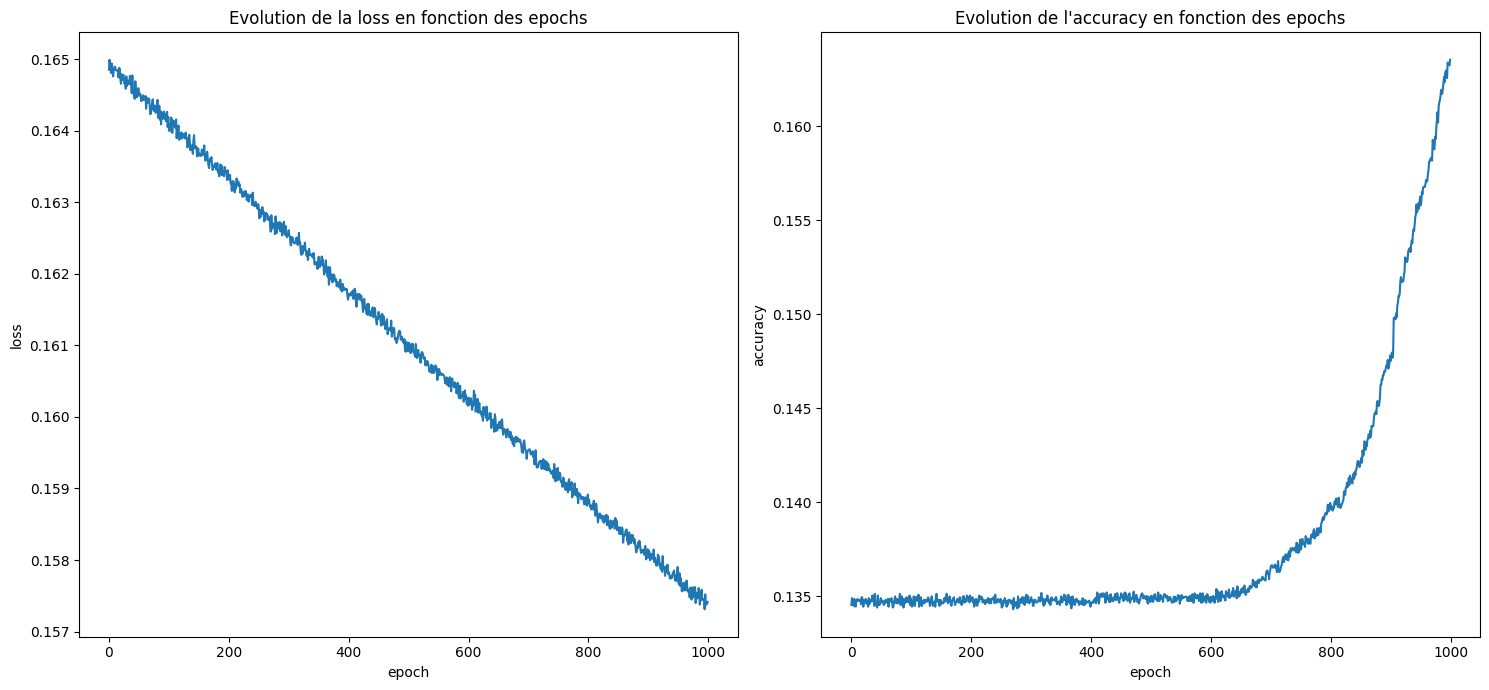

cuda
accuracy train:  0.5866471355160078


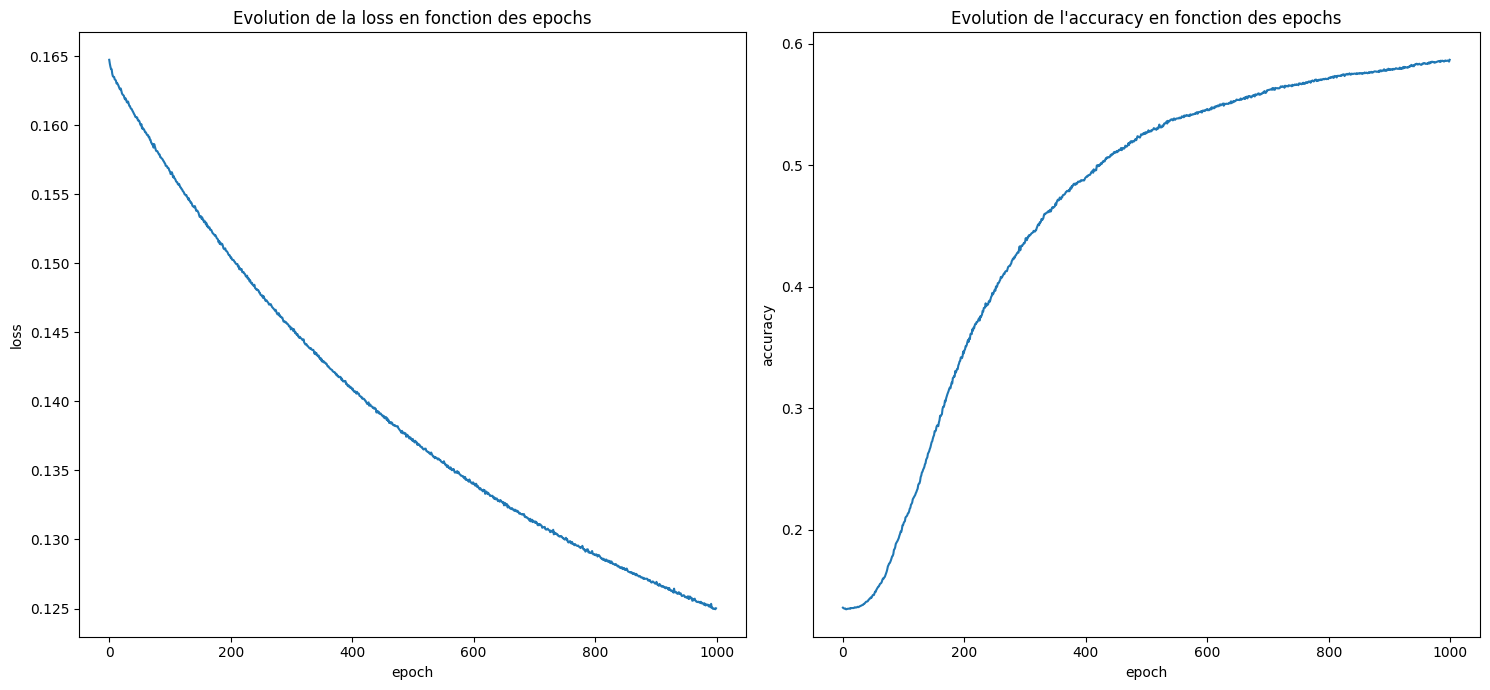

cuda
accuracy train:  0.6837109376986822


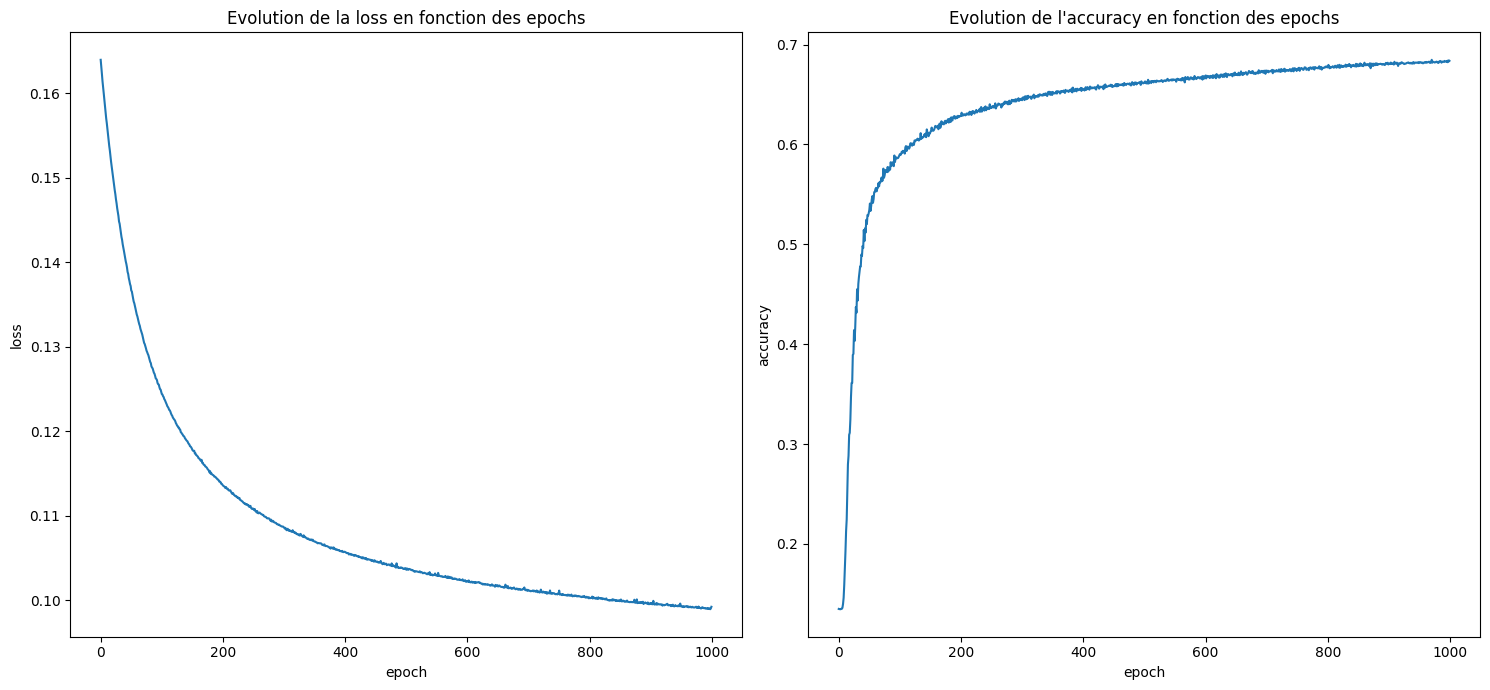

cuda
accuracy train:  0.7236132808029652


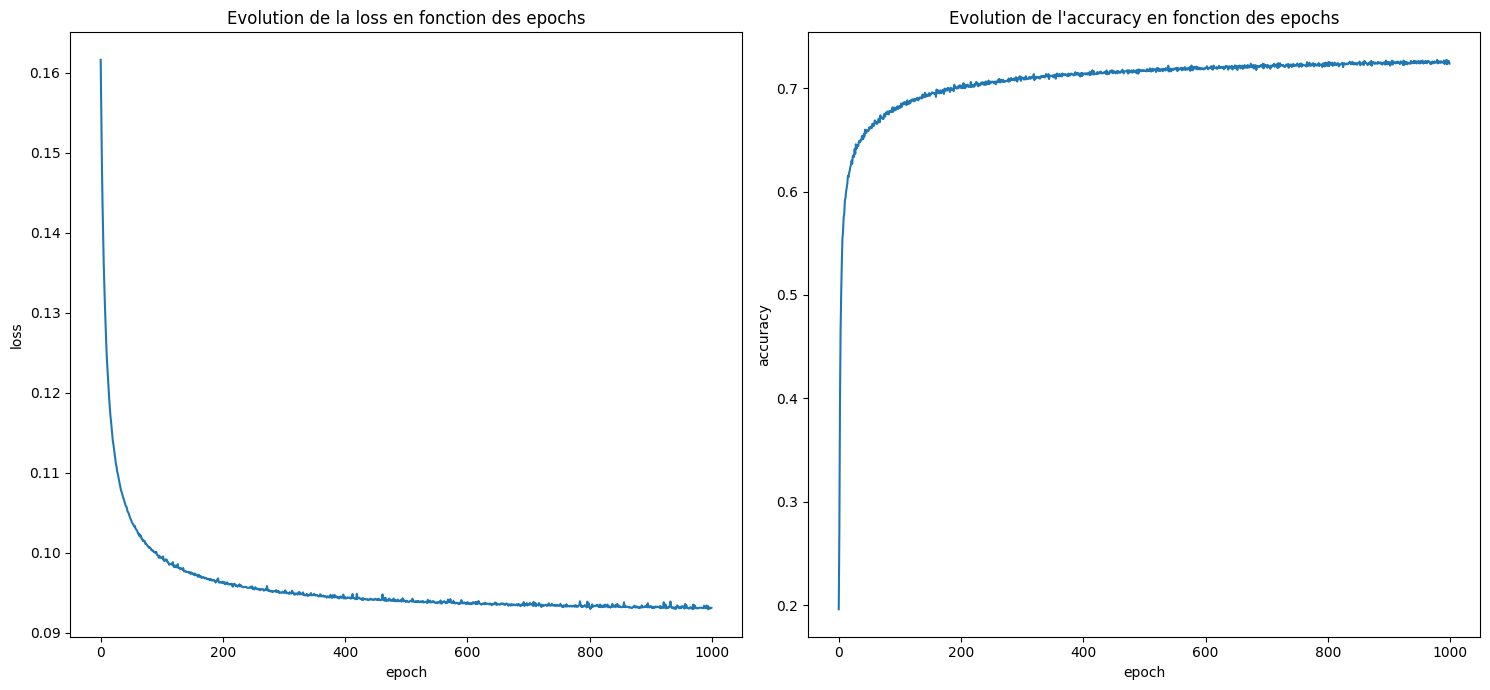

cuda
accuracy train:  0.7303776033222675


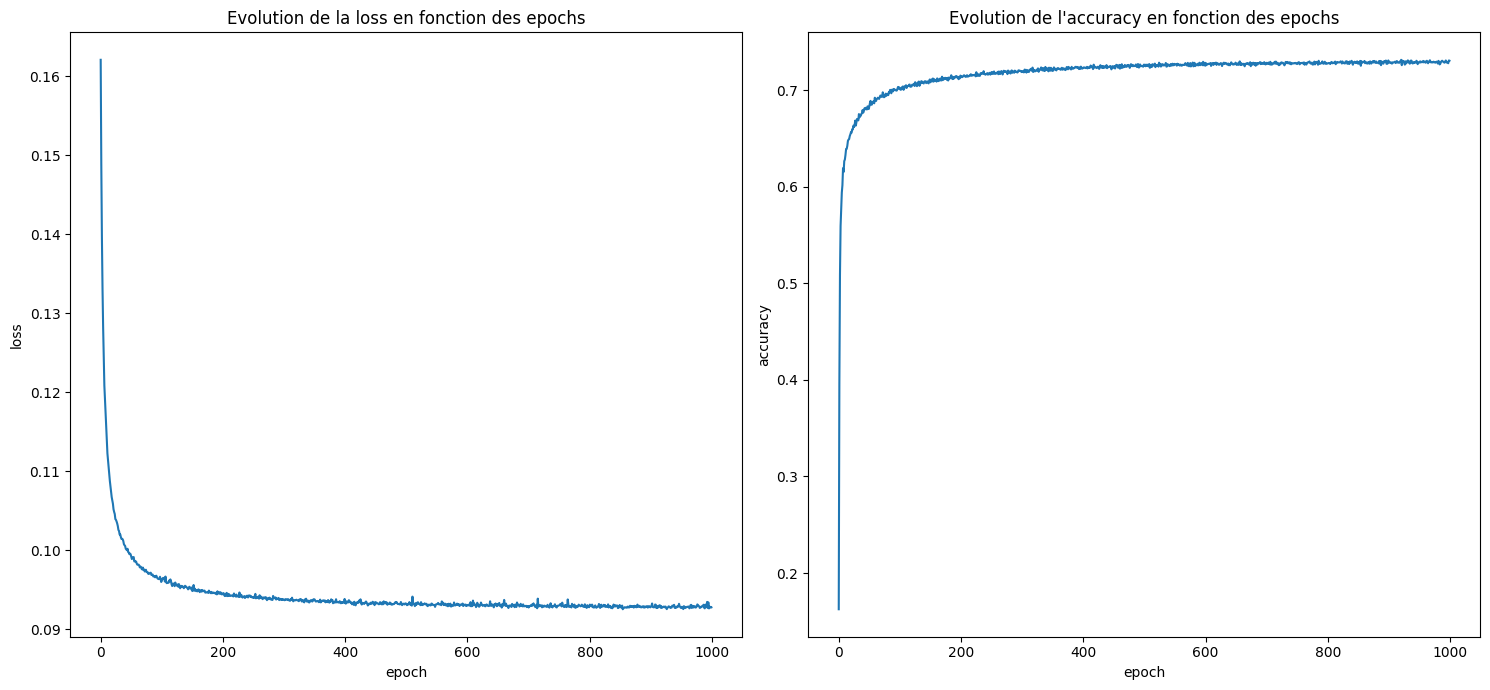

In [23]:
nb_epochs = 1000
models = []
for lr in [1e-3, 1e-2, 1e-1, 1, 2]:   
    model = nn.Linear(input_dim, output_dim)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)
    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models.append(model)

In [24]:
torch.save(model.state_dict(), "model_near_ucf.pth")

In [25]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)

weight
tensor([[-20.3616,  12.1365,  -5.5450,  -4.0283]], device='cuda:0')
bias
tensor([16.3506], device='cuda:0')


Accuracy test:  0.8654
Séparabilité:


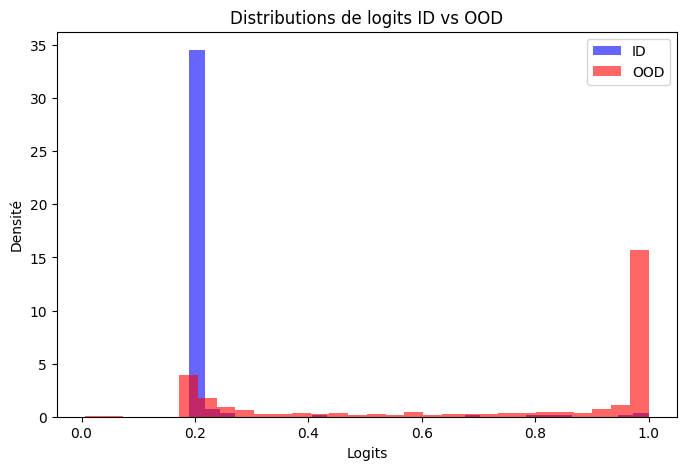

AUC ROC: 0.9489
FPR@TPR95: 0.2524

Correlation ID :  0.824737111884893
Correlation OOD :  0.8382835356014076


,config,tout,video,flow
0,poids_near_ood,12.1365,-5.5450,-4.0283
1,perturbation_near_ood_id,0.0052,0.0035,0.0018
2,perturbation_near_ood_ood,0.0211,0.0137,0.0069


In [26]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, NearOODFramework("near_ood"))

## 2 couches

cuda
accuracy train:  0.21964192700882754


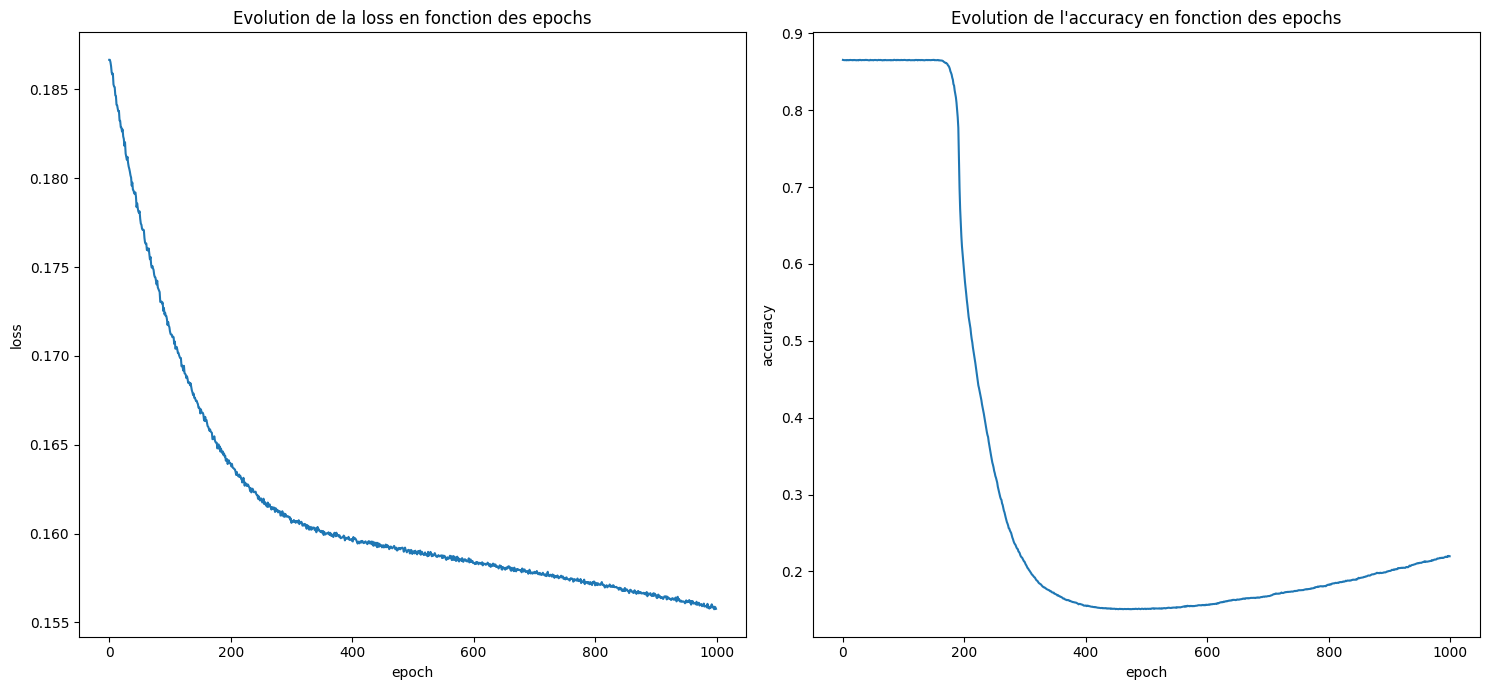

cuda
accuracy train:  0.6939518228173256


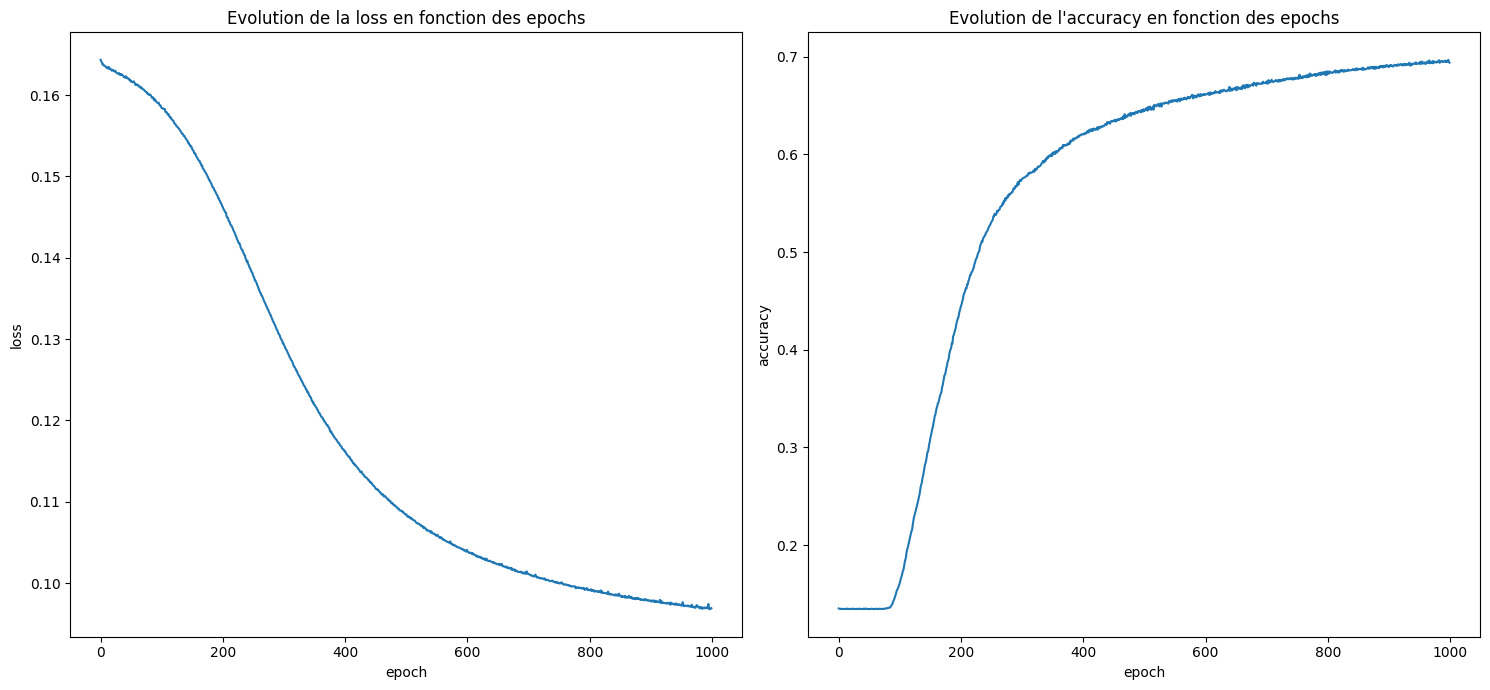

cuda
accuracy train:  0.7804817706346512


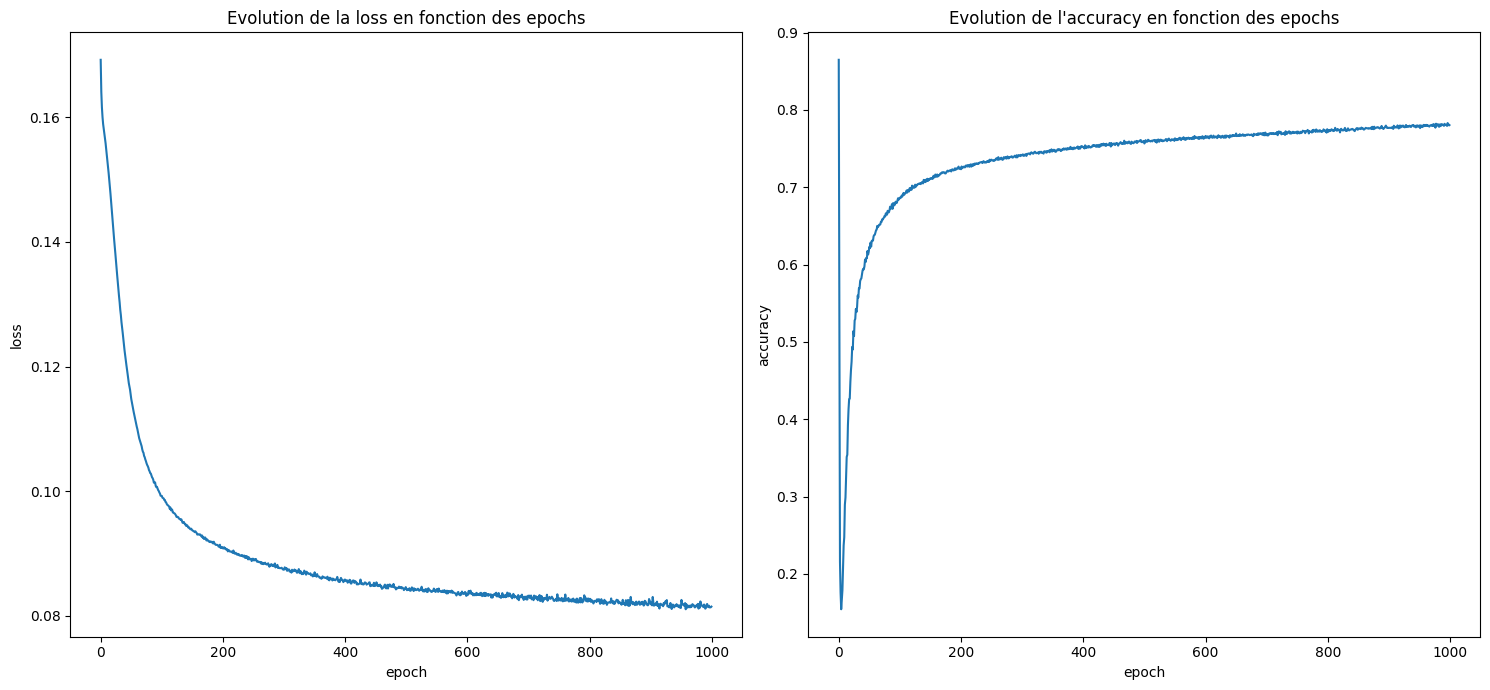

cuda
accuracy train:  0.7899674475193024


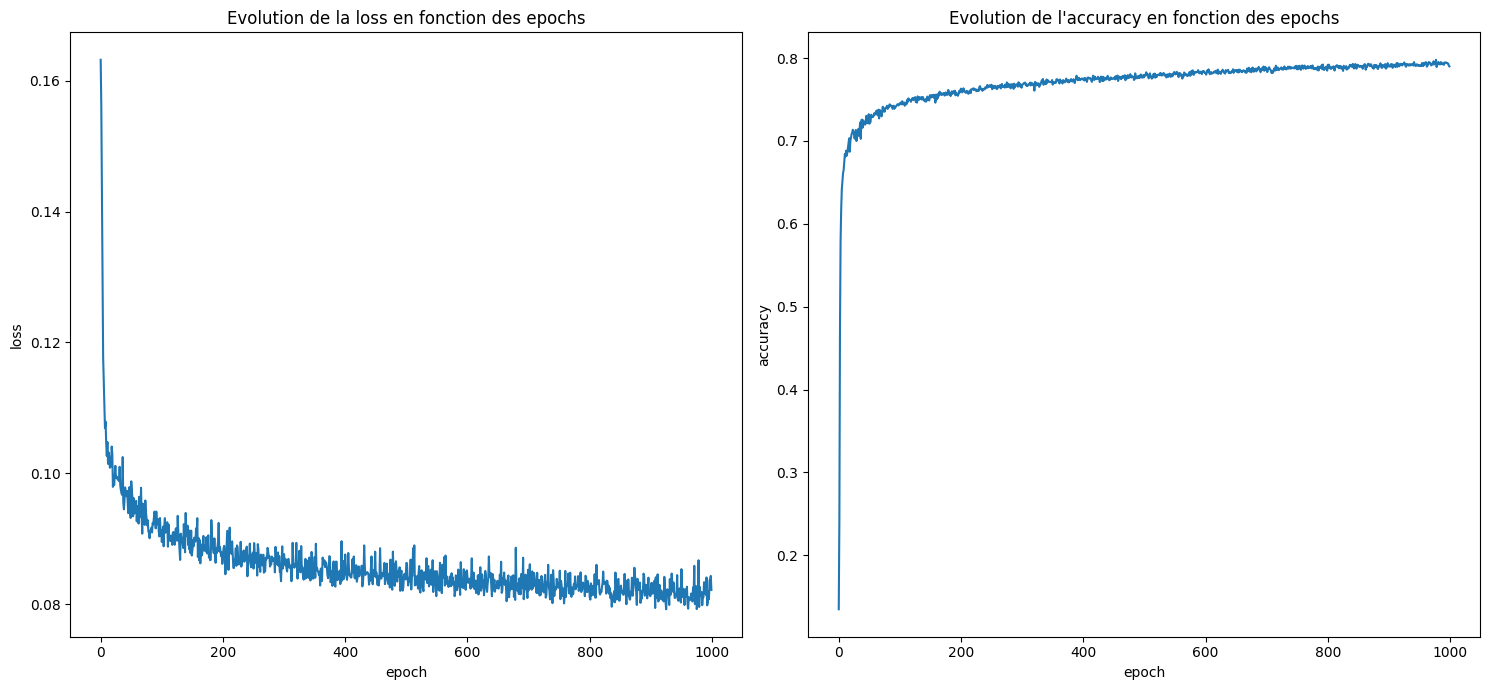

cuda
accuracy train:  0.1348437499254942


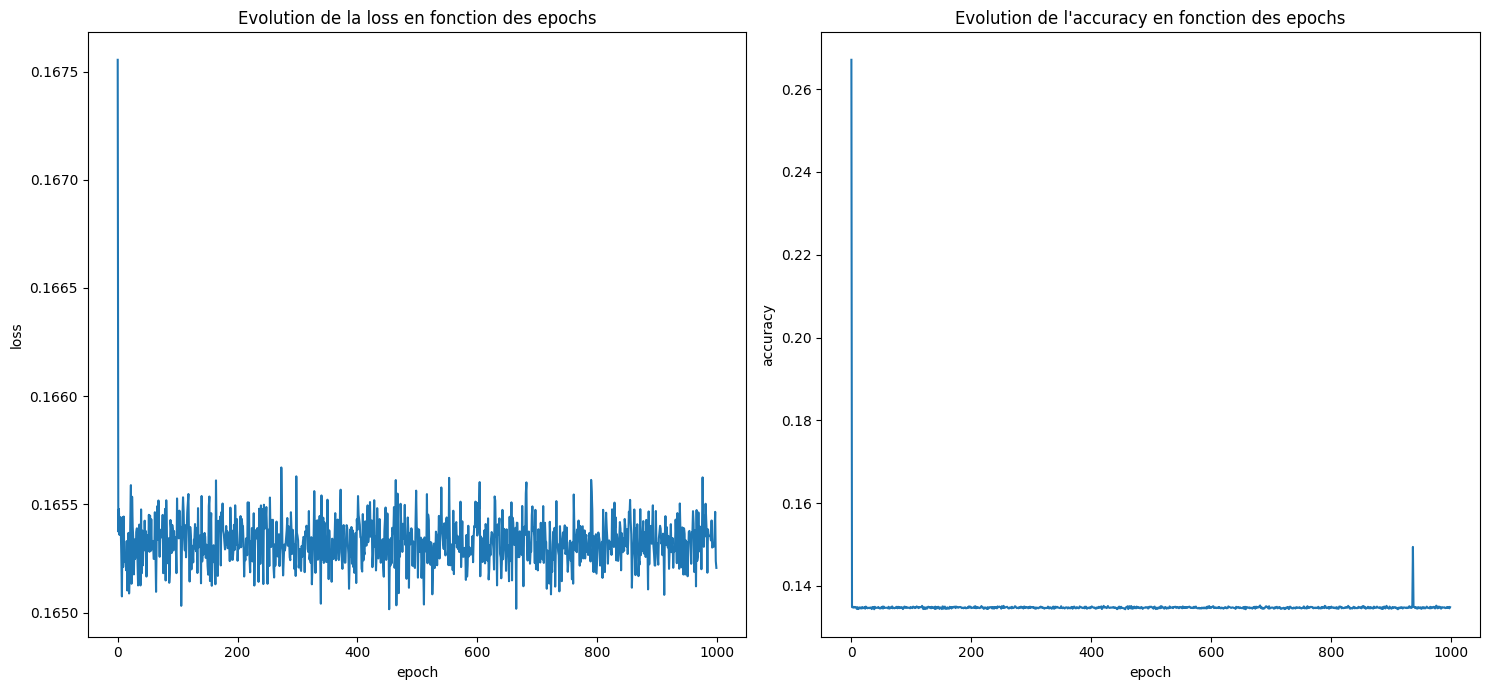

In [27]:
models = []
nb_epochs = 1000
for lr in [1e-3, 1e-2, 1e-1, 1, 2]:    
    model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)
    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models.append(model)

In [28]:
model = models[3]
torch.save(model.state_dict(), "model_near_ucf_2c.pth")

Accuracy test:  0.8654
Séparabilité:


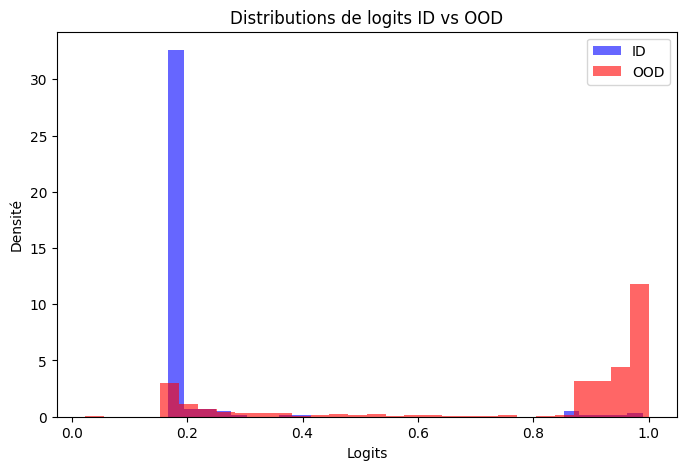

AUC ROC: 0.9506
FPR@TPR95: 0.2427



In [29]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, NearOODFramework("near_ood"), correlations=False)

# Dataset EPIC

## Chargement des données

In [ ]:
data = data_all["EPIC"]

train_dataloader = get_dataloader(data["X_train"], data["y_train"], batch_size=32) #128
test_dataloader = get_dataloader(data["X_test"], data["y_test"], batch_size=32) #128 

1484 elements (array([0., 1.], dtype=float32), array([ 429, 1055]))
372 elements (array([0., 1.], dtype=float32), array([107, 265]))


In [94]:
X_tensor_train = torch.tensor(data['X_train'], dtype=torch.float32)
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
train_dataset = TensorDataset(X_tensor_train, y_tensor_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
print(len(X_tensor_train), "elements", np.unique(y_tensor_train, return_counts=True)) 

1484 elements (array([0., 1.], dtype=float32), array([ 429, 1055]))


In [ ]:
X_tensor_test = torch.tensor(data['X_test'], dtype=torch.float32)
y_tensor_test = torch.tensor(data['y_test'], dtype=torch.float32)
#y_tensor_test = 1-y_tensor_test# pour classification binaire
test_dataset = TensorDataset(X_tensor_test, y_tensor_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)
print(len(X_tensor_test), "elements", np.unique(y_tensor_test, return_counts=True))

372 elements (array([0., 1.], dtype=float32), array([265, 107]))


## Modèle 1 couche

In [6]:
input_dim = 4  #ash sur tous + ash sur aucun + ash video + ash flow + ash audio
hidden_dim = 2
output_dim = 1
# Calcul des poids des classes
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

0.4066350710900474

## Entrainement

cuda
accuracy train:  0.5511968085106383


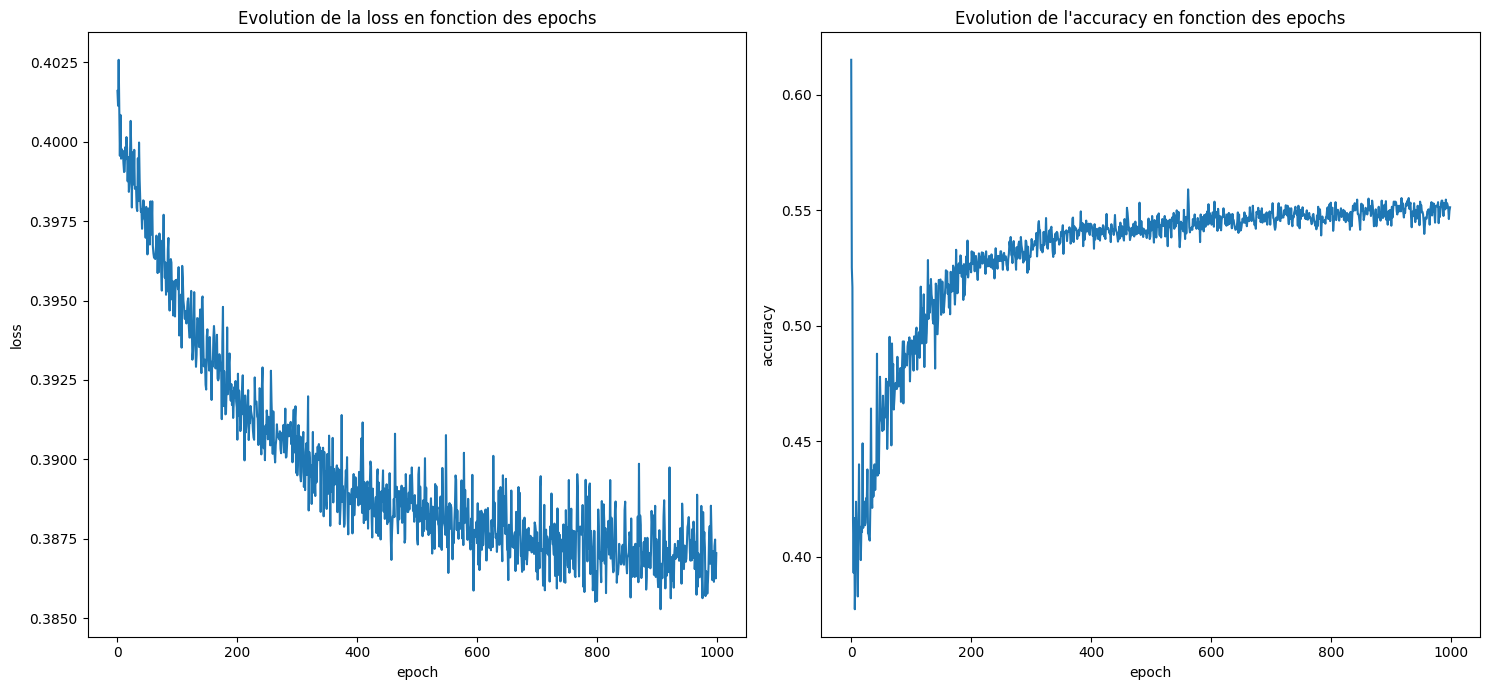

In [14]:
nb_epochs = 1000
model = nn.Linear(input_dim, output_dim)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=200, gamma=0.75)
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs, scheduler)
visualize(plot_loss, plot_acc)

In [15]:
torch.save(model.state_dict(), "model_near_epic.pth")

In [68]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)

weight
tensor([[ 0.3905,  0.4646, -0.3324, -0.2068]])
bias
tensor([0.4208])


Accuracy test:  0.7124
Séparabilité:


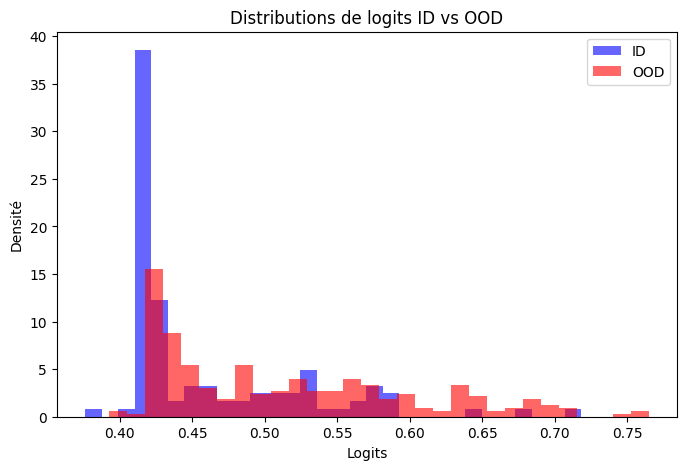

AUC ROC: 0.7218
FPR@TPR95: 0.7196

Correlation ID :  0.9860046251882544
Correlation OOD :  0.9816454684883039


,config,tout,video,flow
0,poids_near_ood,0.5980,0.1041,-0.7989
1,perturbation_near_ood_id,0.0052,0.0035,0.0018
2,perturbation_near_ood_ood,0.0211,0.0137,0.0069


In [16]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, NearOODFramework("near_ood"))

## Modèle 2 Couches

In [ ]:
input_dim = 4 #ash sur tous + ash sur aucun + ash video + ash flow + ash audio
hidden_dim = 2
output_dim = 1

cuda
accuracy train:  0.40691489361702127


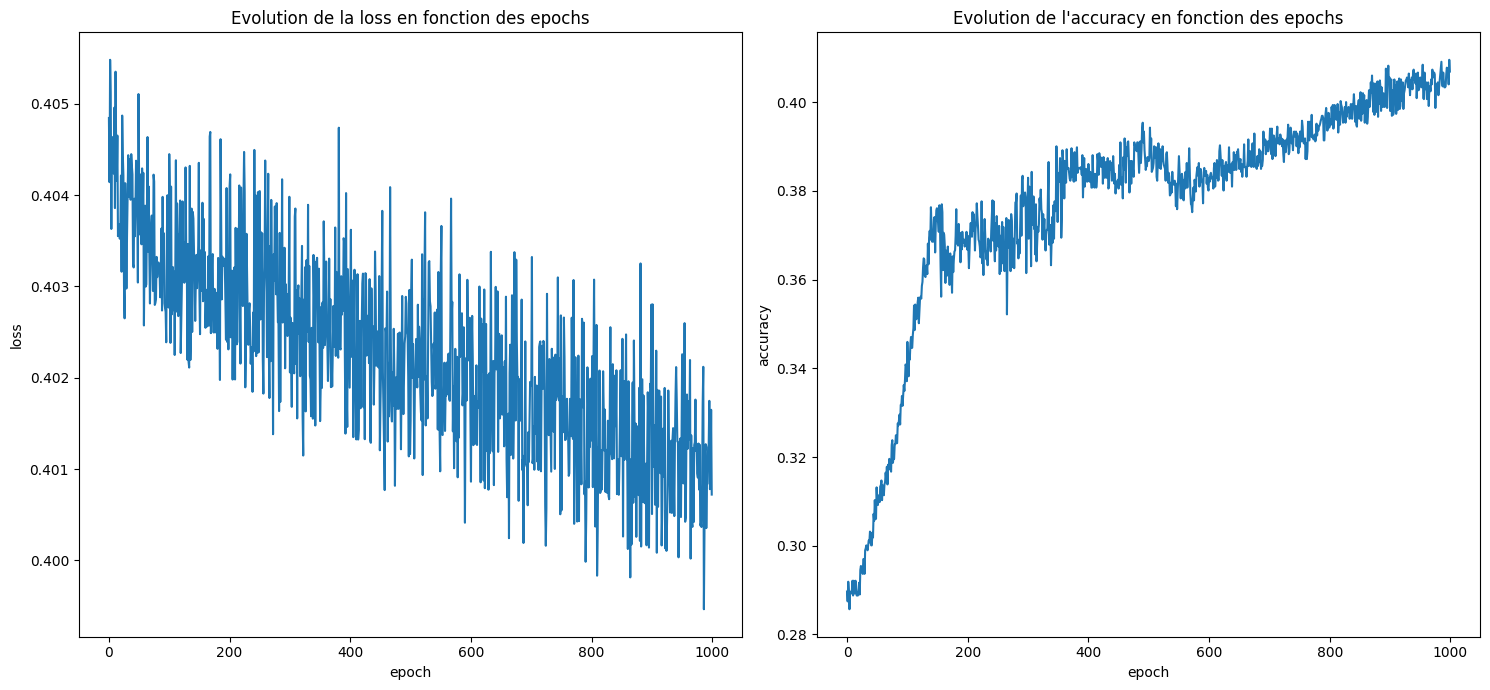

cuda
accuracy train:  0.5651595744680851


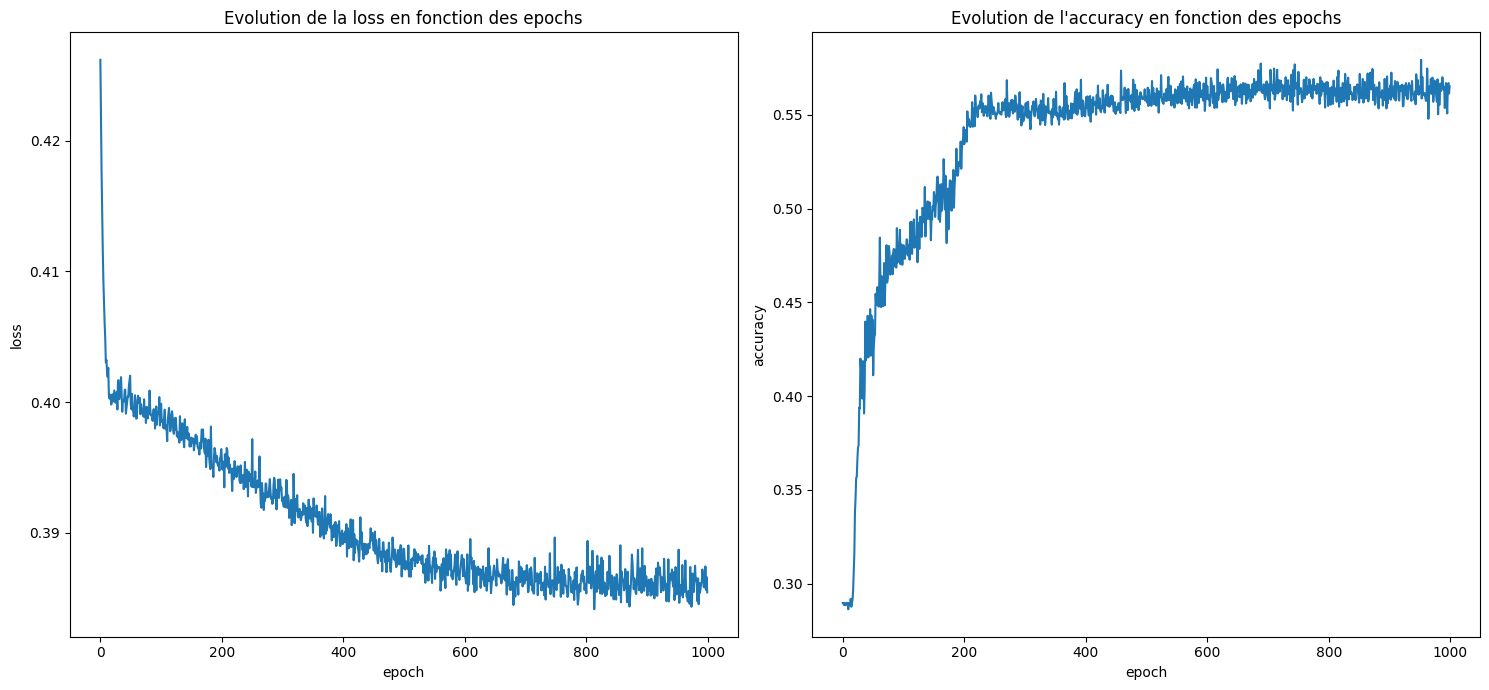

cuda
accuracy train:  0.3690159574468085


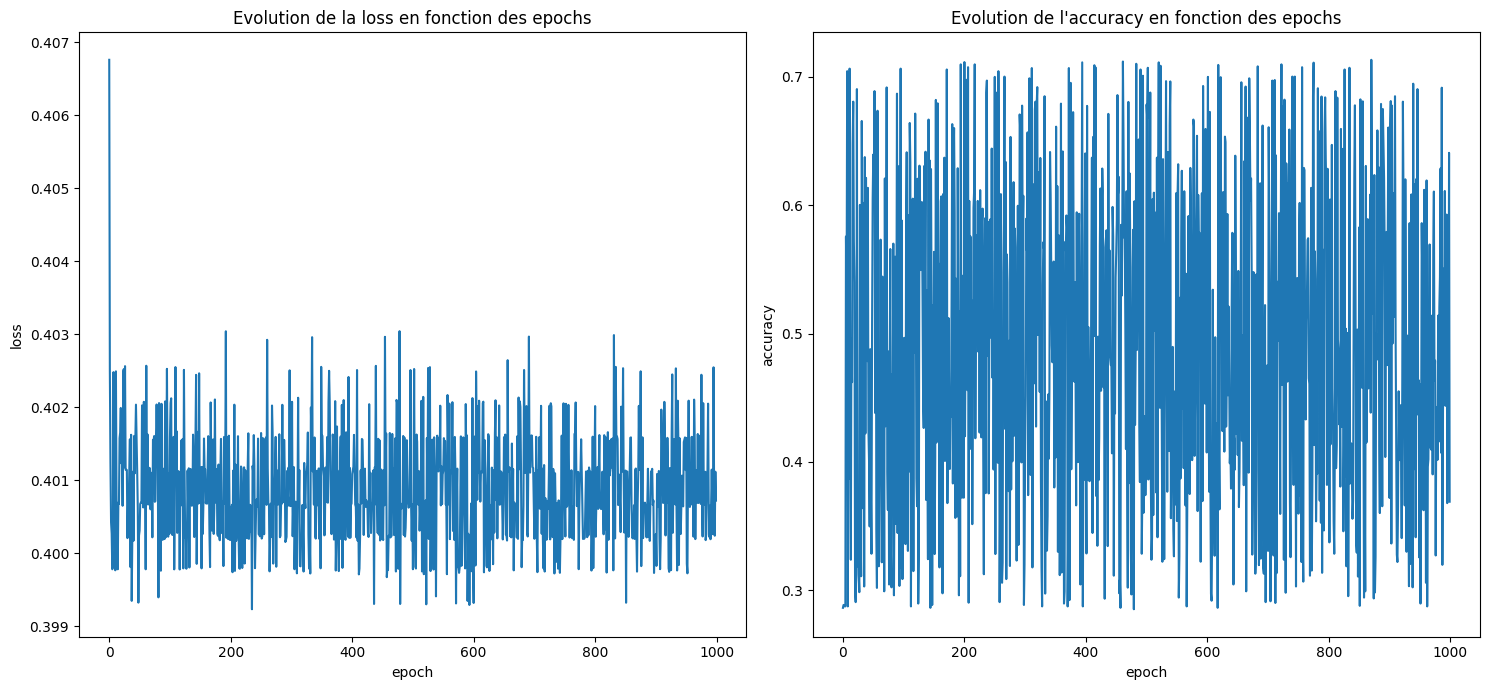

cuda
accuracy train:  0.6764184401390401


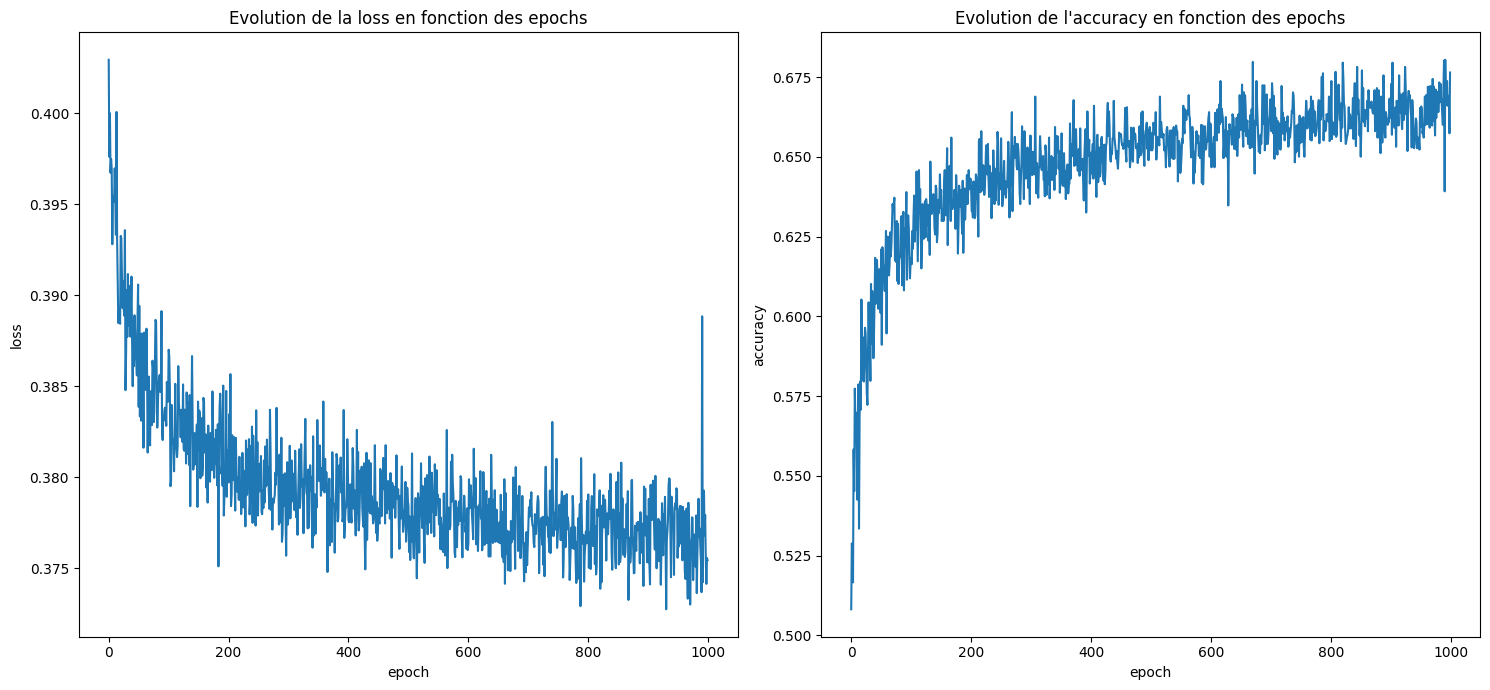

cuda
accuracy train:  0.47850177389510135


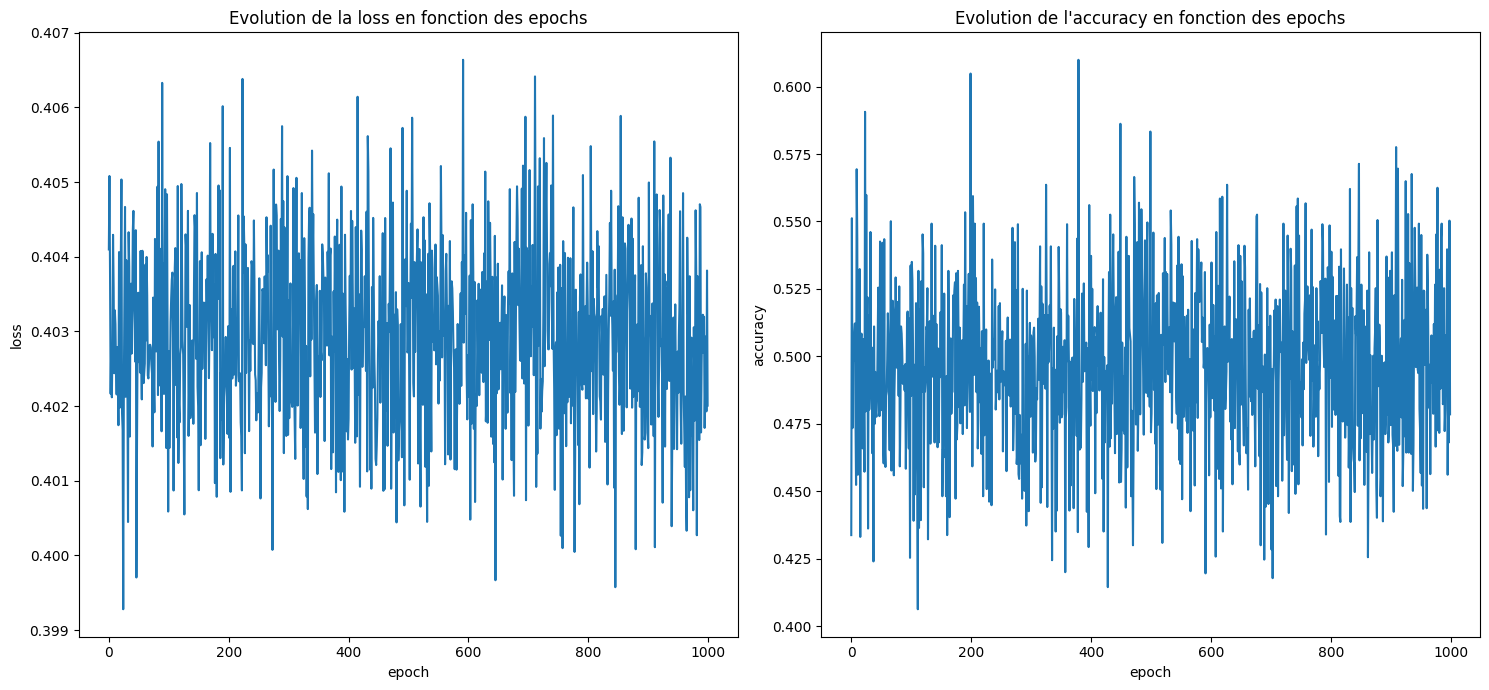

In [17]:
models = []
nb_epochs = 1000
for lr in [1e-3, 1e-2, 1e-1, 1, 2]:    
    model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)
    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models.append(model)

In [18]:
model = models[3]
torch.save(model.state_dict(), "model_near_epic_2c.pth")

Accuracy test:  0.7124
Séparabilité:


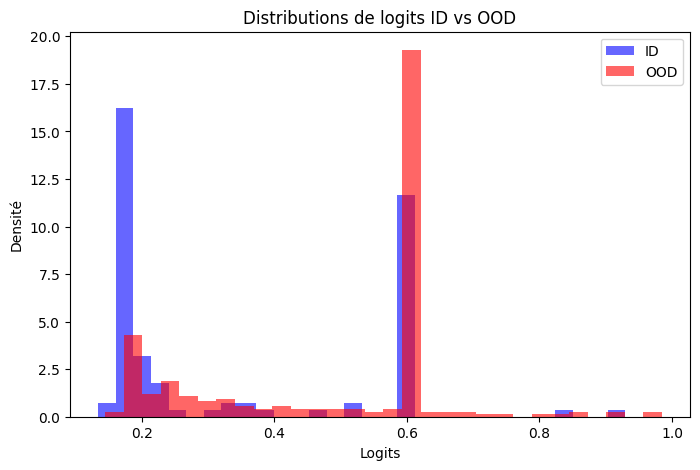

AUC ROC: 0.7109
FPR@TPR95: 0.7103



In [20]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, NearOODFramework("near_ood"), correlations=False)